## Ahmed Adnan, Eugen Erb, Nicolas Huhle

### a) What is an edge and how is it visible in an image and its derivative?
An edge is a place in an image where the intensity changes sharply over a small area and in a specific direction. It appears as a boundary between different regions. Technically, this is where the first derivative of the intensity function is large (the rate of change is large) — it helps to detect how steeply brightness changes at that point​ <br>
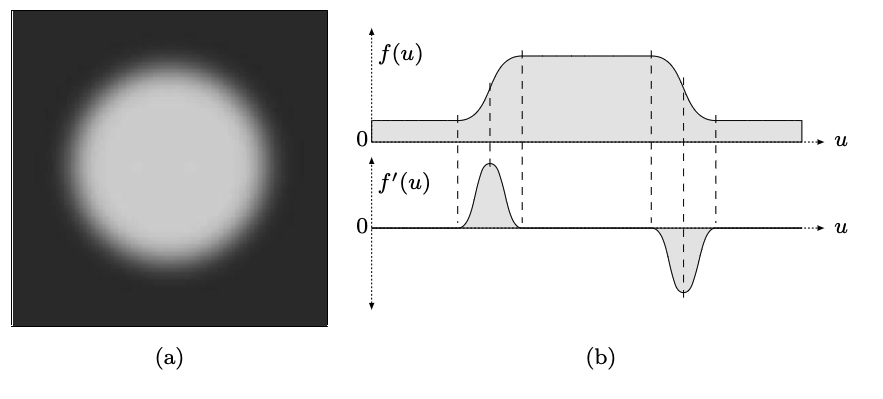

### b) What are the partial derivatives of an image? What do they tell us?
Partial derivatives of an image are the rate of change of pixel intensity along the horizontal (∂I/∂x) and vertical (∂I/∂y) directions. They show how fast and in which direction the intensity is changing, which helps identify edges and their orientations. <br>
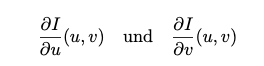

### c) What is the gradient vector of an image?
The gradient vector is a 2D vector formed from the partial derivatives in x and y directions:

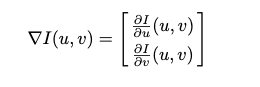 <br>
It points in the direction of the maximum rate of intensity change, and its length tells us how strong the edge is at that point​

### d) How can the edge strength be calculated?
The edge strength is the magnitude of the gradient vector: <br>
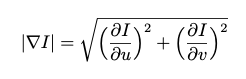 <br>
This gives a scalar value representing how strong the edge is at pixel (u,v)

### e) How can the local edge direction be calculated?
The local edge direction is calculated using the arctangent of the vertical and horizontal gradients: <br>
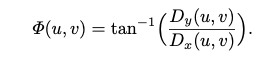 <br>
This angle tells us the orientation of the edge at a specific point​

## 2. Define Sobel filter kernels
below is the code from sobel.py

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import io
import time

def rgb_2_gray(img, mode='lut'):
    if mode == 'lut':
        return np.round(img[:,:,0] * 0.2126 + img[:,:,1] * 0.7152 + img[:,:,2] * 0.0722)
    else:
        return np.round(img[:,:,0] * 0.2126 + img[:,:,1] * 0.587 + img[:,:,2] * 0.114)

##### Sobel filtering function (implementation using loops)


In [21]:
def sobel(img, filter):
    height, width = img.shape
    filter_size = filter.shape[0]
    K = filter_size // 2  # filter "radius"

    # Prepare output image (exclude border based on filter size)
    filtered_img = np.zeros((height - 2*K, width - 2*K))

    # Apply filter using nested loops
    for y in range(K, height - K):             # Skip top/bottom K rows
        for x in range(K, width - K):          # Skip left/right K columns
            value = 0
            for j in range(-K, K + 1):         # Loop vertically over filter
                for i in range(-K, K + 1):     # Loop horizontally over filter
                    value += img[y + j, x + i] * filter[j + K, i + K]  # apply filter
            filtered_img[y - K, x - K] = value  # write to output (adjust for padding)

    # Normalize result to 0–255 for display
    filtered_img = np.abs(filtered_img)
    filtered_img = (filtered_img / np.max(filtered_img)) * 255
    return filtered_img.astype(np.uint8)


##### Define Sobel filters


In [22]:
filter_x = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

filter_y = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
])

##### calculate the duration of calculation for horz and ver.

In [23]:
img = io.imread("lena.jpg")
gray = rgb_2_gray(img)

# Sobel X (horizontal edges)
start = time.time()
sobel_x_result = sobel(gray, filter_x)
end = time.time()
print("X-direction duration in milliseconds:", (end - start) * 1000)

# Sobel Y (vertical edges)
start = time.time()
sobel_y_result = sobel(gray, filter_y)
end = time.time()
print("Y-direction duration in milliseconds:", (end - start) * 1000)

X-direction duration in milliseconds: 1435.97412109375
Y-direction duration in milliseconds: 1421.4377403259277


##### Show both results


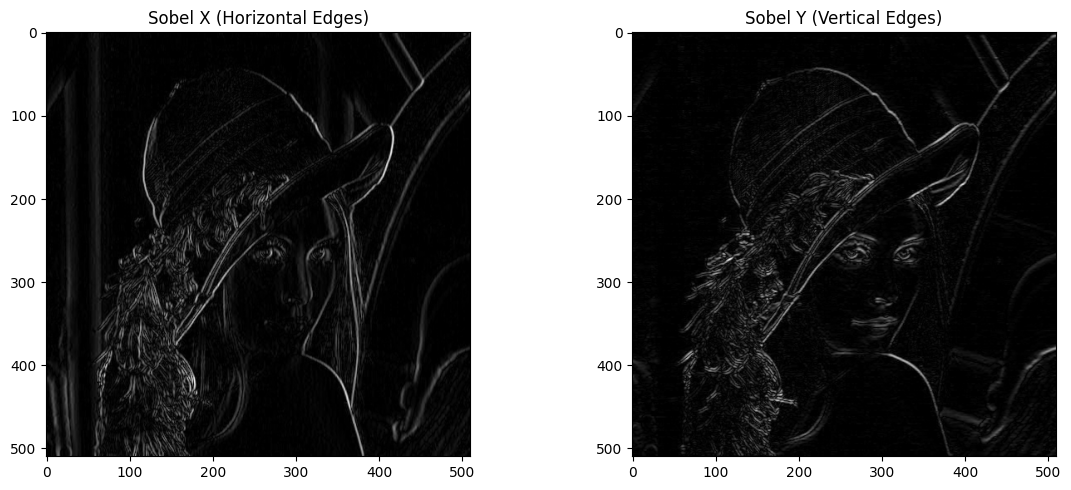

In [24]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.title("Sobel X (Horizontal Edges)")
plt.imshow(sobel_x_result, cmap='gray')

plt.subplot(1, 2, 2)
plt.title("Sobel Y (Vertical Edges)")
plt.imshow(sobel_y_result, cmap='gray')

plt.tight_layout()
plt.show()


#### To compare the performance of having for loops with using np.sum function and multiplication with the previous sobel implementation

In [25]:
def sobel2(img, filt):
    height, width = img.shape
    filter_size = filt.shape[0]
    K = filter_size // 2

    out_img = np.zeros((height - 2 * K, width - 2 * K))

    # Loop over valid center pixels
    for y in range(K, height - K):
        for x in range(K, width - K):
            region = img[y - K : y + K + 1, x - K : x + K + 1]
            value = np.sum(region * filt)
            
            #result (shifted due to K)
            out_img[y - K, x - K] = value

    out_img = np.abs(out_img)
    out_img = (out_img / np.max(out_img)) * 255

    return out_img.astype(np.uint8)


In [26]:
# Sobel2 X (horizontal edges)
start = time.time()
sobel2_x_result = sobel2(gray, filter_x)
end = time.time()
print("X-direction duration in milliseconds:", (end - start) * 1000)

# Sobel2 Y (vertical edges)
start = time.time()
sobel2_y_result = sobel2(gray, filter_y)
end = time.time()
print("Y-direction duration in milliseconds:", (end - start) * 1000)

X-direction duration in milliseconds: 2384.838104248047
Y-direction duration in milliseconds: 2126.6469955444336


##### did not notice a huge difference, most of the time having 4 loops was even faster

### Compute Gradient Magnitude
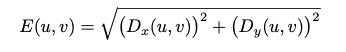

In [32]:
def gradient_magnitude(Gx, Gy):
    """
    Computes the gradient magnitude image from Gx and Gy.
    
    Parameters:
        Gx (2D np.array): Sobel result in X direction
        Gy (2D np.array): Sobel result in Y direction

    Returns:
        Magnitude image (2D np.uint8)
    """
    # Convert to float for precision
    Gx = Gx.astype(np.float32)
    Gy = Gy.astype(np.float32)

    # gradient magnitude
    magnitude = np.sqrt(Gx**2 + Gy**2)

    magnitude = (magnitude / np.max(magnitude)) * 255

    return magnitude.astype(np.uint8)

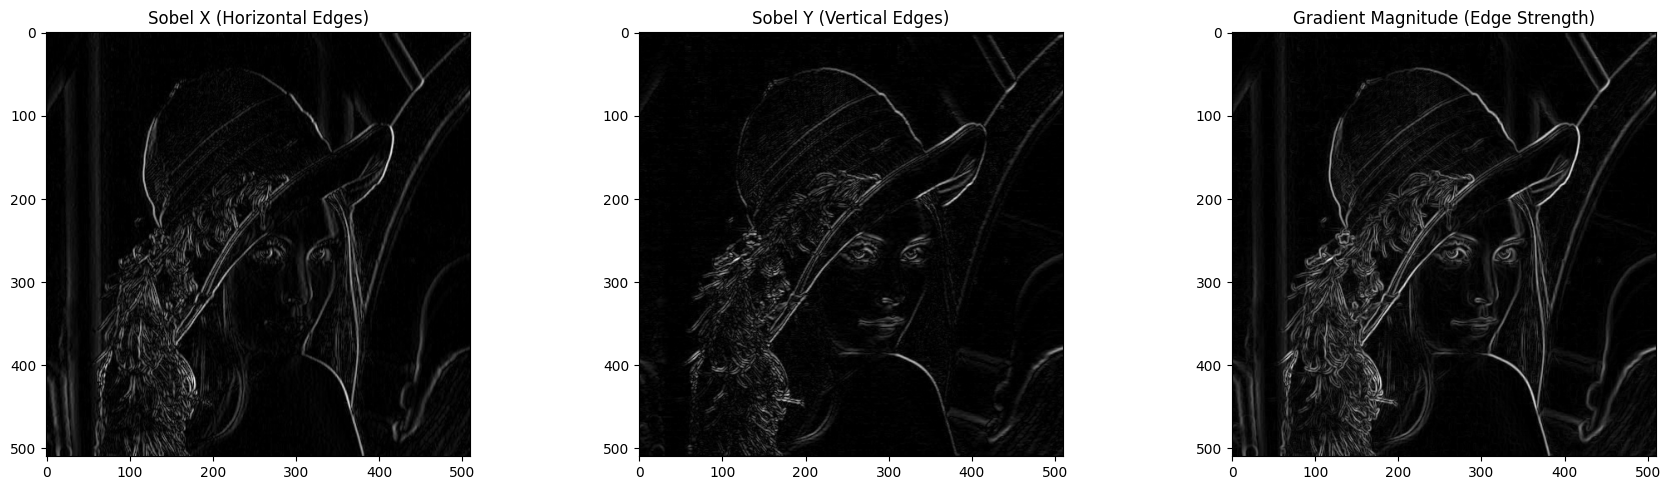

In [31]:
Gx = sobel(gray, filter_x)
Gy = sobel(gray, filter_y)
Gmag = gradient_magnitude(Gx, Gy)

plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
plt.title("Sobel X (Horizontal Edges)")
plt.imshow(sobel_x_result, cmap='gray')

plt.subplot(1, 3, 2)
plt.title("Sobel Y (Vertical Edges)")
plt.imshow(sobel_y_result, cmap='gray')

plt.subplot(1, 3, 3)
plt.title("Gradient Magnitude (Edge Strength)")
plt.imshow(Gmag, cmap='gray')

plt.tight_layout()
plt.show()

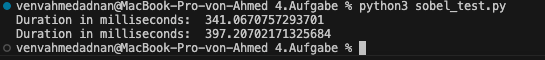

### not in task
calculating the gradient direction<br>
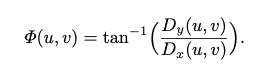

In [33]:
def gradient_direction(Gx, Gy):
    """
    Computes the gradient direction (angle in degrees) at each pixel.
    
    Parameters:
        Gx (2D np.array): Sobel X result
        Gy (2D np.array): Sobel Y result

    Returns:
        Angle image (2D np.float32), scaled to 0–255 for visualization
    """
    # Convert to float for precision
    Gx = Gx.astype(np.float32)
    Gy = Gy.astype(np.float32)

    # Compute direction in radians, then convert to degrees
    direction = np.arctan2(Gy, Gx)  # angle in radians (-π to π)
    direction_deg = np.degrees(direction)  # convert to degrees (-180 to 180)

    # Optional: normalize to 0–255 for display
    direction_norm = (direction_deg + 180) / 360 * 255

    return direction_norm.astype(np.uint8)

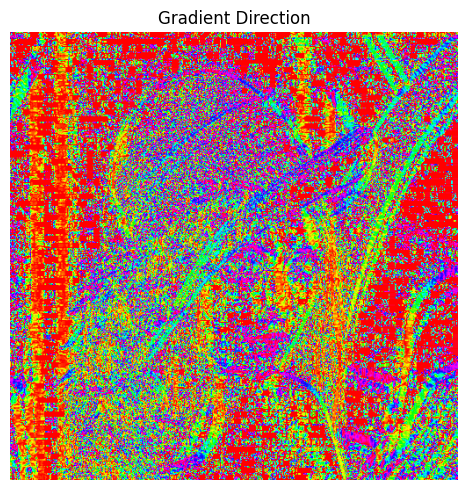

In [37]:
# Apply Sobel filters
sobel_x_result = sobel(gray, filter_x)
sobel_y_result = sobel(gray, filter_y)

# Compute gradient magnitude and direction
Gmag = gradient_magnitude(sobel_x_result, sobel_y_result)
Gdir = gradient_direction(sobel_x_result, sobel_y_result)

# Plot results
plt.figure(figsize=(20, 5))

plt.title("Gradient Direction")
plt.imshow(Gdir, cmap='hsv')  # hsv colormap shows angles nicely
plt.axis('off')

plt.tight_layout()
plt.show()


In [42]:
def masked_gradient_direction(Gx, Gy, threshold=180):
    """
    Visualizes gradient direction with HSV, masking out low edge magnitudes.

    Parameters:
        Gx, Gy (ndarray): Sobel X and Y results
        threshold (float): Minimum magnitude to keep direction visible

    Returns:
        Colored HSV image showing edge directions clearly
    """
    Gx = Gx.astype(np.float32)
    Gy = Gy.astype(np.float32)

    # Compute magnitude and direction
    magnitude = np.sqrt(Gx**2 + Gy**2)
    direction = np.arctan2(Gy, Gx)
    direction_deg = np.degrees(direction)
    direction_norm = (direction_deg + 180) / 360  # scale to 0–1 (HSV hue)

    # Create HSV image (Hue = direction, Saturation = 1, Value = magnitude mask)
    hsv = np.zeros((*Gx.shape, 3), dtype=np.float32)
    hsv[..., 0] = direction_norm  # Hue
    hsv[..., 1] = 1.0             # Full saturation
    hsv[..., 2] = (magnitude > threshold).astype(float)  # Value = 1 only where strong edges

    # Convert HSV to RGB for display
    import matplotlib.colors as mcolors
    rgb = mcolors.hsv_to_rgb(hsv)
    return rgb


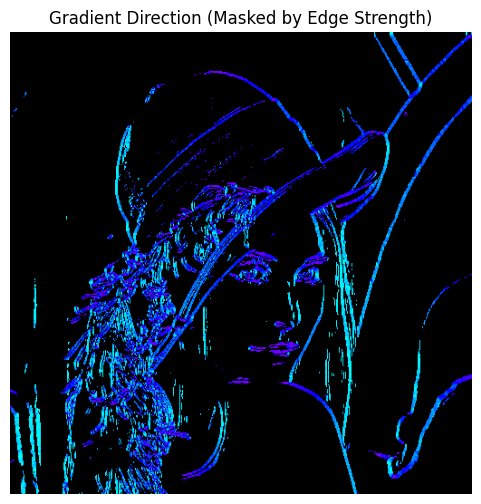

In [43]:
rgb_dir = masked_gradient_direction(sobel_x_result, sobel_y_result, threshold=40)

plt.figure(figsize=(6, 6))
plt.title("Gradient Direction (Masked by Edge Strength)")
plt.imshow(rgb_dir)
plt.axis('off')
plt.show()
